In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import gzip
import os
import time
import random

In [ ]:
!unzip archive.zip  #Распаковка архивов

Archive:  archive.zip
  inflating: t10k-images-idx3-ubyte/t10k-images-idx3-ubyte  
  inflating: t10k-images.idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte  
  inflating: t10k-labels.idx1-ubyte  
  inflating: train-images-idx3-ubyte/train-images-idx3-ubyte  
  inflating: train-images.idx3-ubyte  
  inflating: train-labels-idx1-ubyte/train-labels-idx1-ubyte  
  inflating: train-labels.idx1-ubyte  


In [ ]:
#Считываем датасет и преобразуем его

def load_idx_images(path):  #читаем файл изображений
    with open(path, 'rb') as f:  #открываем бинарный файл
        data = f.read() #читаем его в data
        magic, num, rows, cols = np.frombuffer(data[:16], dtype='>i4') #читаем первые 16 байт (np.frombuffer интерпретирует бинарные фпйлы в массив NumPy) / dtype='>i4' показывает порядок signed int, 4 байта
        images = np.frombuffer(data[16:], dtype=np.uint8) #пиксели
        print(images.shape)
        images = images.reshape(num, rows, cols) #превращаем в 3х мерный массив
        return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        data = f.read()
        magic, num = np.frombuffer(data[:8], dtype='>i4')
        labels = np.frombuffer(data[8:], dtype=np.uint8)
        return labels

In [ ]:

#обучающие изображения
X_train = load_idx_images("train-images.idx3-ubyte")
y_train = load_idx_labels("train-labels.idx1-ubyte")

#тестовые изображения и метки
X_test = load_idx_images("t10k-images.idx3-ubyte")
y_test = load_idx_labels("t10k-labels.idx1-ubyte")


(47040000,)
(7840000,)


Train images: 60000
Train labels: 60000
Test images: 10000
Test labels: 10000


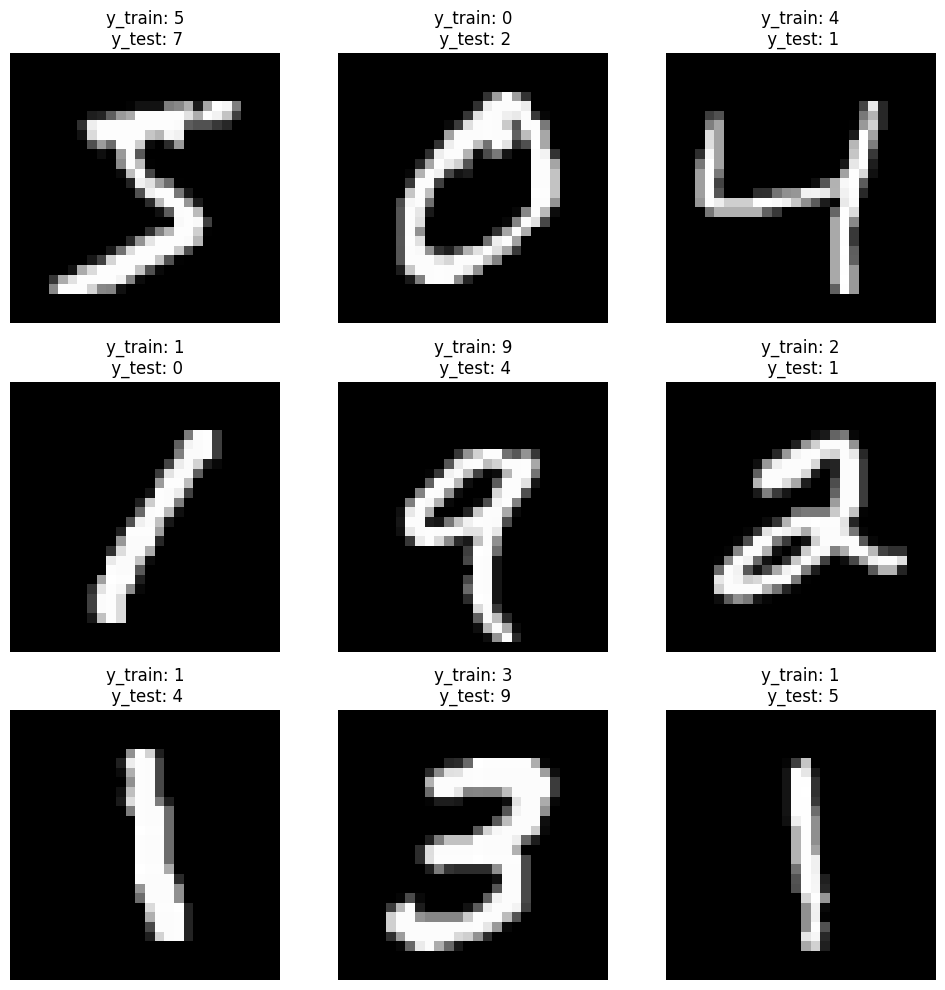

In [ ]:
print("Train images:", len(X_train))
print("Train labels:", len(y_train))

print("Test images:", len(X_test))
print("Test labels:", len(y_test))

# Покажем первые 9 изображений из обучающего набора
num_examples = 9 #количество изображений

plt.figure(figsize=(10,10)) # холст

for i in range(num_examples):
    plt.subplot(3, 3, i+1)               # 3x3 сетка
    plt.imshow(X_train[i], cmap='gray')  # изображение в оттенках серого
    plt.title(f"y_train: {y_train[i]}\n y_test: {y_test[i]}")    # метка для изображения
    plt.axis('off')                      # отключаем оси

plt.tight_layout() #Подгоняет отступы
plt.show()


In [ ]:
#нормализация
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [ ]:
#Функции активации

def ReLU(x): # На скрытом слое
    return np.maximum(0, x)

def softmax(x):
    # Вычитаем максимум для числовой стабильности
    x_exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    # Делим на сумму по строке, чтобы получить вероятности
    return x_exp / np.sum(x_exp, axis=1, keepdims=True)

In [ ]:
#Функции ошибки
def crossEntropy(y_pred, y_true):
    m = y_pred.shape[0] #y_pred - массив предсказанный сетью после softmax (определяем размер батча) Его форма (batch_size, num_classes):
    # создаём one-hot для правильных классов
    y_onehot = np.zeros_like(y_pred)
    y_onehot[np.arange(m), y_true] = 1
    # кросс-энтропия
    loss = -np.sum(y_onehot * np.log(y_pred + 1e-8)) / m #  + 1e-8 чтобы не было деление на 0 Берём среднюю ошибку по батчу, чтобы loss не зависел от размера батча
    return loss

In [ ]:
def diffReLU(x):
    return np.where(x > 0, 1, 0)

In [ ]:
def accuracy(y_pred, y_true): #точность
    y_pred = np.argmax(y_pred, axis=1)
    return np.mean(y_pred == y_true)

In [ ]:
#Нейронная сеть
class Neuro:
    def __init__(self, input_size, hidden_size, output_size):
        # веса
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size) #веса + масштабирование весов для relu
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X): #прямой проход принимает входной массив (батч (batch_size, input_size))
        self.X = X #сохраняем для обратного распространения
        self.Z1 = X @ self.W1 + self.b1 #1 скрытый
        self.A1 = ReLU(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2 #2 выходной слой
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_true): #обратное распространение
        m = y_true.shape[0] # кол-во примеров которые мы изучаем
        # one-hot для правильных классов
        y_onehot = np.zeros_like(self.A2) #для классов вероятностей для выходного слоя. Начинаем с конца
        y_onehot[np.arange(m), y_true] = 1

        # Градиент выхода
        dZ2 = self.A2 - y_onehot #уменьшаем веса по формуле softmax + cross

        '''
        dW2 — как ошибка зависит от весов второго слоя

        db2 — как ошибка зависит от смещений второго слоя
        '''
        self.dW2 = self.A1.T @ dZ2 / m # m - число примеров А1 активации скрытого слоя градиенты ошибки на выходе на выходи H на С (c - классы а H кол-во нейронов скрытых) | градиент функции потерь по весам выходного слоя.
        self.db2 = np.sum(dZ2, axis=0, keepdims=True) / m  # Градиент функции потерь по вектору смещений b₂.

        # Градиент скрытого слоя
        dA1 = dZ2 @ self.W2.T #Передаём ошибку на скрытый слой
        dZ1 = dA1 * diffReLU(self.Z1) #учитываем relu
        self.dW1 = self.X.T @ dZ1 / m #Градиенты весов и смещений скрытого слоя
        self.db1 = np.sum(dZ1, axis=0, keepdims=True) / m


    def update(self, learning_rate): #Шаг градиентного спуска
        self.W1 -= learning_rate * self.dW1 #self.dW1 — градиент функции потерь по этим весам, вычисленный в backward
        self.b1 -= learning_rate * self.db1 #-= означает идём в сторону уменьшения ошибки (градиентный спуск)
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2


    def train(self, X_batch, y_batch, learning_rate): #выполняет один полный шаг обучения сети на одном батче данных.
      self.forward(X_batch) #прямой проход
      self.backward(y_batch) #обратный проход
      self.update(learning_rate) #Обновление параметров сети с использованием градиентов:
      return crossEntropy(self.A2, y_batch), accuracy(self.A2, y_batch) #Возвращает метрики для текущего батча: crossEntropy — средняя ошибка сети на батче accuracy — точность предсказаний сети на батче

    def predict(self, X):
        A2 = self.forward(X)
        return np.argmax(A2, axis=1)

In [ ]:
input_size = 28 * 28  # входной слой (w x h)
output_size = 10      # выходной слой (k - нейронов соответствует количеству классов изображений)
hidden_size = 300     # Скрытый слой (s)
batch_size = 32       # Размер пачки данных
learning_rate = 0.1   # скорость обучения
num_epochs = 20       # кол-во эпох

ns = Neuro(input_size, hidden_size, output_size)

In [ ]:
# Тренировка сети
num_samples = X_train.shape[0]
X_train_flat = X_train.reshape(num_samples, -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

for epoch in range(num_epochs):
    # Перемешиваем данные
    idx = np.random.permutation(num_samples)
    X_train_flat = X_train_flat[idx]
    y_train = y_train[idx]

    batch_losses = []
    batch_accuracy = []

    for i in range(0, num_samples, batch_size):
        X_batch = X_train_flat[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        loss, acc = ns.train(X_batch, y_batch, learning_rate)
        batch_losses.append(loss)
        batch_accuracy.append(acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {np.mean(batch_losses):.4f}, Accuracy: {np.mean(batch_accuracy):.4f}")

Epoch 1/20, Loss: 0.2867, Accuracy: 0.9169
Epoch 2/20, Loss: 0.1342, Accuracy: 0.9616
Epoch 3/20, Loss: 0.0940, Accuracy: 0.9726
Epoch 4/20, Loss: 0.0721, Accuracy: 0.9790
Epoch 5/20, Loss: 0.0584, Accuracy: 0.9833
Epoch 6/20, Loss: 0.0477, Accuracy: 0.9863
Epoch 7/20, Loss: 0.0398, Accuracy: 0.9891
Epoch 8/20, Loss: 0.0331, Accuracy: 0.9910
Epoch 9/20, Loss: 0.0281, Accuracy: 0.9930
Epoch 10/20, Loss: 0.0236, Accuracy: 0.9945
Epoch 11/20, Loss: 0.0200, Accuracy: 0.9957
Epoch 12/20, Loss: 0.0169, Accuracy: 0.9969
Epoch 13/20, Loss: 0.0145, Accuracy: 0.9974
Epoch 14/20, Loss: 0.0127, Accuracy: 0.9981
Epoch 15/20, Loss: 0.0108, Accuracy: 0.9985
Epoch 16/20, Loss: 0.0094, Accuracy: 0.9990
Epoch 17/20, Loss: 0.0081, Accuracy: 0.9993
Epoch 18/20, Loss: 0.0071, Accuracy: 0.9994
Epoch 19/20, Loss: 0.0063, Accuracy: 0.9995
Epoch 20/20, Loss: 0.0055, Accuracy: 0.9998


In [ ]:
train_pred = ns.predict(X_train_flat)
test_pred = ns.predict(X_test_flat)

print("Train accuracy:", np.mean(train_pred == y_train))
print("Test accuracy:", np.mean(test_pred == y_test))


Train accuracy: 0.99955
Test accuracy: 0.9812


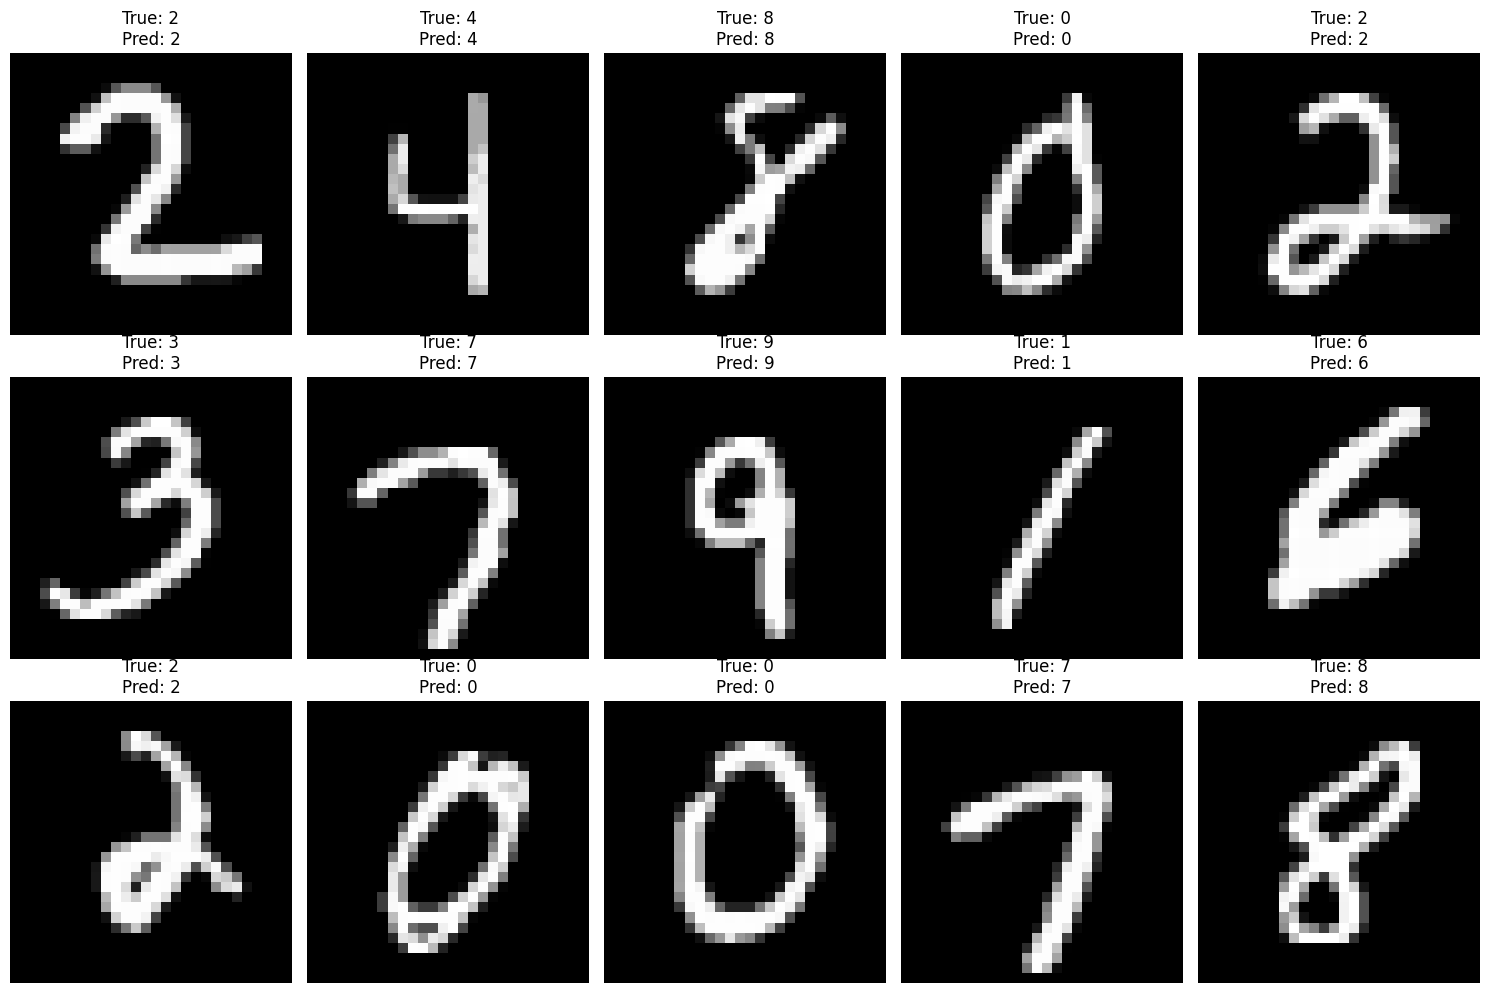

In [ ]:
num_examples = 15  # количество изображений
plt.figure(figsize=(15, 10))

for i in range(num_examples):
    r = random.randint(0, X_test.shape[0]-1)
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[r], cmap='gray')
    plt.title(f"True: {y_test[r]}\nPred: {test_pred[r]}")
    plt.axis('off')

plt.tight_layout()
plt.show()